# **Project Goal**

Use pretrained CNN model like ResNet / VGG16 and detect plant leaf disease images using PlantVillage dataset.

# **Step** 1: Install Required Libraries

In [2]:
pip install tensorflow matplotlib numpy pandas scikit-learn

# **Step 2: Download Dataset**

**Use:**

PlantVillage

**Contains classes like:**

Tomato Early Blight
Tomato Healthy
Potato Late Blight
Pepper Healthy
etc.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
os.listdir('/content/drive/MyDrive/Datasets/PlantVillage')

['Tomato_healthy', 'Tomato_Early_blight', 'Tomato_Late_blight']

# **Step 3: Import Libraries**

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
import matplotlib.pyplot as plt

# **Step 4: Data Preprocessing**

In [5]:
img_size = (224,224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/Datasets/PlantVillage",
    target_size=(224,224),
    batch_size=32,
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/Datasets/PlantVillage",
    target_size=(224,224),
    batch_size=32,
    subset='validation'
)

Found 3601 images belonging to 3 classes.
Found 899 images belonging to 3 classes.


# **Step 5: Load Pretrained Model**

In [6]:
#Option A: ResNet50
base_model = ResNet50(weights='imagenet',
                      include_top=False,
                      input_shape=(224,224,3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [7]:
#Freeze Layers
for layer in base_model.layers:
    layer.trainable = False

# **Step 6: Build Final Model**

In [8]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(128, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dense(train_data.num_classes, activation='softmax')
])

# **Step 7: Choose Optimizer**

In [9]:
#Adam
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Try later:**

SGD
RMSprop

# **Step 8: Train Model**

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2370s 21s/step - accuracy: 0.3882 - loss: 1.3650 - val_accuracy: 0.3337 - val_loss: 1.2477
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 76s 678ms/step - accuracy: 0.4196 - loss: 1.2123 - val_accuracy: 0.3615 - val_loss: 1.1844
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 75s 668ms/step - accuracy: 0.4182 - loss: 1.1696 - val_accuracy: 0.5606 - val_loss: 1.1412
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 76s 674ms/step - accuracy: 0.4468 - loss: 1.1326 - val_accuracy: 0.5562 - val_loss: 1.1049
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 75s 662ms/step - accuracy: 0.4588 - loss: 1.1149 - val_accuracy: 0.5662 - val_loss: 1.1133
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 76s 677ms/step - accuracy: 0.4704 - loss: 1.1010 - val_accuracy: 0.5072 - val_loss: 1.0824
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 76s 674ms/step - accuracy: 0.4796 - loss: 1.0919 - val_accuracy: 0.5195 - val_loss: 1.0688
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 77s 681ms/step - accuracy: 0.4807 - loss: 1

# **Step 9: Plot Accuracy Graph**

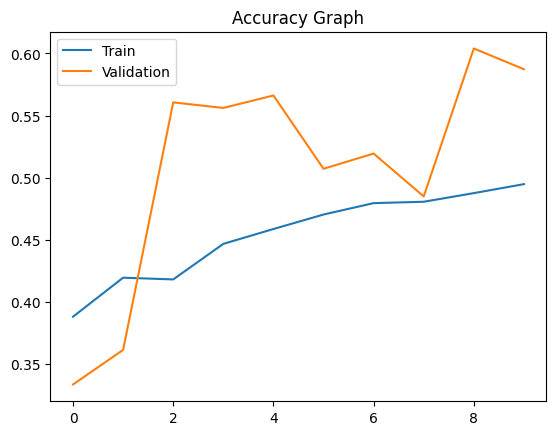

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Accuracy Graph")
plt.show()

# **Step 10: Fine Tuning (Unfreeze Last Layers)**

In [12]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 110s 808ms/step - accuracy: 0.6873 - loss: 0.7639 - val_accuracy: 0.4449 - val_loss: 1.0977
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 77s 678ms/step - accuracy: 0.7673 - loss: 0.5328 - val_accuracy: 0.3537 - val_loss: 1.1003
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 77s 685ms/step - accuracy: 0.7967 - loss: 0.4759 - val_accuracy: 0.5050 - val_loss: 1.0176
Epoch 4/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 78s 687ms/step - accuracy: 0.8237 - loss: 0.4385 - val_accuracy: 0.7842 - val_loss: 0.5843
Epoch 5/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 77s 687ms/step - accuracy: 0.8403 - loss: 0.4007 - val_accuracy: 0.8743 - val_loss: 0.3676
